# 02 · Keşifsel analiz

Puanlamaya geçmeden önce verinin bize ne söylediğine bakıyoruz:
**insanlar ne zaman hareket ediyor, hangi ilçeler yoğun, toplu taşıma nerede zorlanıyor?**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30, "display.width", 160)

from db import baglan, sorgu
from gorsel import *
stil_uygula()
con = baglan()

# İlçe kodlarını (ör. "EYUPSULTAN") grafiklerde düzgün Türkçe adla göstermek için
import geopandas as gpd
from utils import PROCESSED
ilceler = gpd.read_parquet(PROCESSED / "referans" / "ilceler.parquet")
AD = dict(zip(ilceler["ilce"], ilceler["ilce_adi"]))

sorgu(con, "03_ilce_yolculuk.sql")          # ilce_yolculuk tablosunu oluşturur
talep = sorgu(con, "04_ilce_talep_aktarma.sql")
yuk = sorgu(con, "05_otobus_yuk.sql")       # hat_dilim_yuk tablosunu da oluşturur

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 1. Gün içinde yolcu eğrisi
Hafta içi ortalama bir günde saat saat biniş sayısı, ulaşım türüne göre.

tur,Deniz,Metrobüs,Otobüs,Raylı sistem
saat,,,,
8,0.0,98.0,322.0,310.0
13,0.0,53.0,188.0,166.0
18,0.0,109.0,243.0,350.0


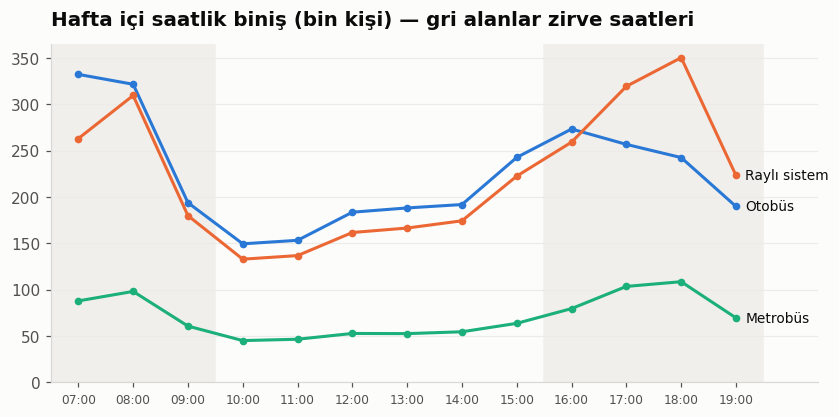

In [2]:
saatlik = con.execute("""
    SELECT saat,
           CASE WHEN yol_turu = 'RAYLI' THEN 'Raylı sistem'
                WHEN istasyon IS NOT NULL THEN 'Metrobüs'
                WHEN yol_turu = 'OTOYOL' THEN 'Otobüs'
                ELSE 'Deniz' END AS tur,
           SUM(yolcu_sayisi) / COUNT(DISTINCT tarih) / 1000 AS bin_yolcu
    FROM yolculuk GROUP BY ALL
""").df().pivot(index="saat", columns="tur", values="bin_yolcu")

fig, ax = plt.subplots(figsize=(9, 4))
for tur, renk in [("Otobüs", MAVI), ("Raylı sistem", TURUNCU), ("Metrobüs", CAMGOBEGI)]:
    ax.plot(saatlik.index, saatlik[tur], color=renk, marker="o", markersize=4)
    ax.annotate(tur, (saatlik.index[-1], saatlik[tur].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color=YAZI, fontsize=9)
for bas, son in [(7, 9.99), (16, 19.99)]:
    ax.axvspan(bas - 0.5, son + 0.5 - 0.99, color="#f0efec", zorder=0)
ax.set_xticks(range(7, 20), [f"{s:02d}:00" for s in range(7, 20)], rotation=0, fontsize=8)
ax.set_xlim(6.5, 20.5)
ax.set_ylim(0, None)
ax.set_title("Hafta içi saatlik biniş (bin kişi) — gri alanlar zirve saatleri")
kaydet(fig, "02_saatlik_egri")
(saatlik.loc[[8, 13, 18]]).round(0)

**Gözlem:** Sabah zirvesi 07:00–09:00 arasında **keskin** (saat 9'da toplam biniş 08:00'ın %60'ına düşüyor), akşam zirvesi ise
16:00–19:00'a **yayılmış**. İnsanlar işe aynı saatte gidiyor ama dönüş saatleri daha dağınık. Akşam zirvesinde raylı sistem otobüsü geçiyor. Bu, paylaşımlı ulaşım için sabahın **kısa ve keskin**, akşamın **uzun** bir talep penceresi olduğunu gösteriyor.

## 2. Talebin ilçelere dağılımı

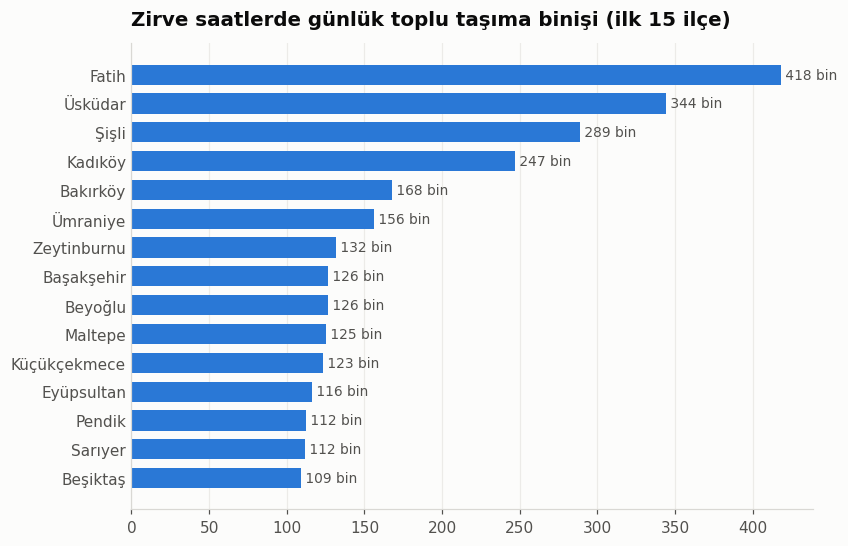

In [3]:
t = talep[~talep["ilce"].isin(["SILIVRI", "SILE", "CATALCA", "ADALAR"])].copy()
t["ad"] = t["ilce"].map(AD)
ilk15 = t.nlargest(15, "zirve_binis")

fig, ax = plt.subplots(figsize=(8, 5.5))
yatay_cubuk(ax, ilk15["ad"], ilk15["zirve_binis"] / 1000, fmt="{:.0f} bin")
ax.set_title("Zirve saatlerde günlük toplu taşıma binişi (ilk 15 ilçe)")
kaydet(fig, "02_ilce_talep")

Fatih, Üsküdar, Şişli ve Kadıköy en çok binişin yapıldığı ilçeler. Ancak bu ilçelerin çoğu **aktarma ve iş merkezi**:
insanlar burada yaşadığı için değil, buradan geçtiği ya da burada çalıştığı için biniyor. Bunu bir sonraki grafikte görüyoruz.

## 3. Kişi başı kullanım: ilçe merkez mi, yatakhane mi?

,ad,nufus_15_64,zirve_binis,kisi_basi_zirve_binis
20,Esenyurt,688927,81477.0,0.118
29,Esenler,311274,44400.0,0.143
34,Arnavutköy,228614,32700.0,0.143
31,Beylikdüzü,288862,42036.0,0.146
25,Gaziosmanpaşa,348743,54989.0,0.158
23,Sultangazi,376274,59855.0,0.159
33,Sultanbeyli,248997,39545.0,0.159
21,Bahçelievler,414487,70862.0,0.171


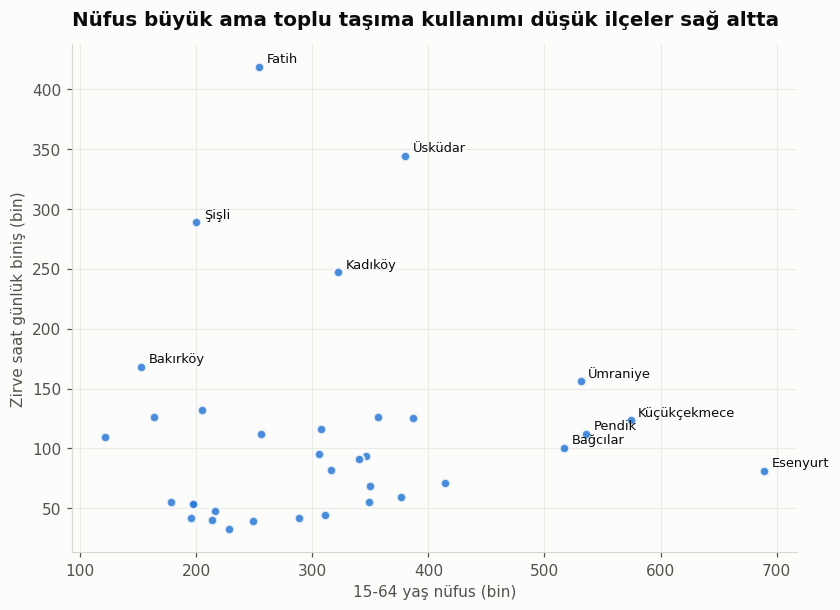

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(t["nufus_15_64"] / 1000, t["zirve_binis"] / 1000, s=40, color=MAVI, alpha=0.85,
           edgecolor=ZEMIN, linewidth=1.5)
etiketle = set(t.nlargest(6, "zirve_binis")["ilce"]) | set(t.nlargest(5, "nufus_15_64")["ilce"])
for _, r in t[t["ilce"].isin(etiketle)].iterrows():
    ax.annotate(r["ad"], (r["nufus_15_64"] / 1000, r["zirve_binis"] / 1000),
                xytext=(5, 3), textcoords="offset points", fontsize=8.5, color=YAZI)
ax.set_xlabel("15-64 yaş nüfus (bin)")
ax.set_ylabel("Zirve saat günlük biniş (bin)")
ax.grid(axis="x", visible=True)
ax.set_title("Nüfus büyük ama toplu taşıma kullanımı düşük ilçeler sağ altta")
kaydet(fig, "02_nufus_vs_binis")
t[["ad", "nufus_15_64", "zirve_binis", "kisi_basi_zirve_binis"]].sort_values("kisi_basi_zirve_binis").head(8)

**Önemli bulgu:** Kişi başı toplu taşıma kullanımı en düşük ilçeler **Esenyurt** (İstanbul'un en kalabalık ilçesi), Esenler, Arnavutköy,
Beylikdüzü, Gaziosmanpaşa ve Sultangazi. Bu ilçelerde 15-64 yaş kişi başına günde 0,12-0,16 zirve binişi var; Fatih'te bu oran 1,6. Bu iki şekilde yorumlanabilir: ya insanlar özel araç ve servis kullanıyor, ya da toplu taşıma
bu ilçelerde **yeterince erişilebilir değil**. Erişim mesafesine bakınca hangisi olduğu netleşecek.

## 4. Erişim: duraktan en yakın raylı sistem / metrobüs istasyonuna mesafe

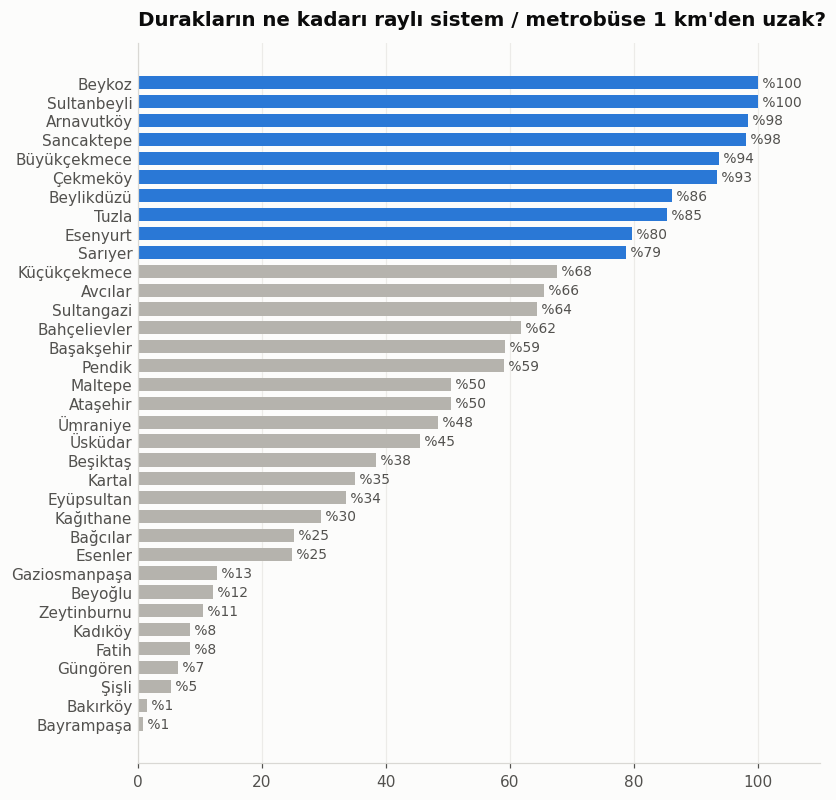

In [5]:
from metrics import erisim_ilce, trafik_ilce
erisim = erisim_ilce()
e = erisim[~erisim["ilce"].isin(["SILIVRI", "SILE", "CATALCA", "ADALAR"])].copy()
e["ad"] = e["ilce"].map(AD)
e = e.sort_values("uzak_durak_payi", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8.5))
yatay_cubuk(ax, e["ad"], e["uzak_durak_payi"] * 100, fmt="%{:.0f}",
            vurgu=set(e.head(10)["ad"]))
ax.set_title("Durakların ne kadarı raylı sistem / metrobüse 1 km'den uzak?")
ax.set_xlim(0, 110)
kaydet(fig, "02_erisim")

Sultanbeyli, Beykoz, Sancaktepe ve Arnavutköy'de durakların neredeyse **tamamı** raylı sisteme 1 km'den (12-15 dk yürüyüş) uzak.
Büyükçekmece, Çekmeköy, Beylikdüzü, Tuzla ve Esenyurt'ta da bu oran %80 ve üzerinde. Bu ilçelerde insanlar toplu taşımaya **otobüs + aktarma** ile ulaşıyor.

## 5. Otobüs yükü: hangi hatlar zirvede en yoğun?

,hat_kodu,gunluk_yolcu,sefer,sefer_basi,yuk
0,36L,2874.0,8.0,359.0,3.592645
1,98,3504.0,11.0,319.0,3.185236
2,14ES,4252.0,15.0,283.0,2.834481
3,19S,6256.0,23.0,272.0,2.720175
4,79B,2352.0,10.0,235.0,2.352062
5,146,3882.0,18.0,216.0,2.156400
6,14B,5043.0,24.0,210.0,2.101105
7,93,2058.0,10.0,206.0,2.057899
8,146B,1220.0,6.0,203.0,2.034134
9,98H,2415.0,12.0,201.0,2.012474


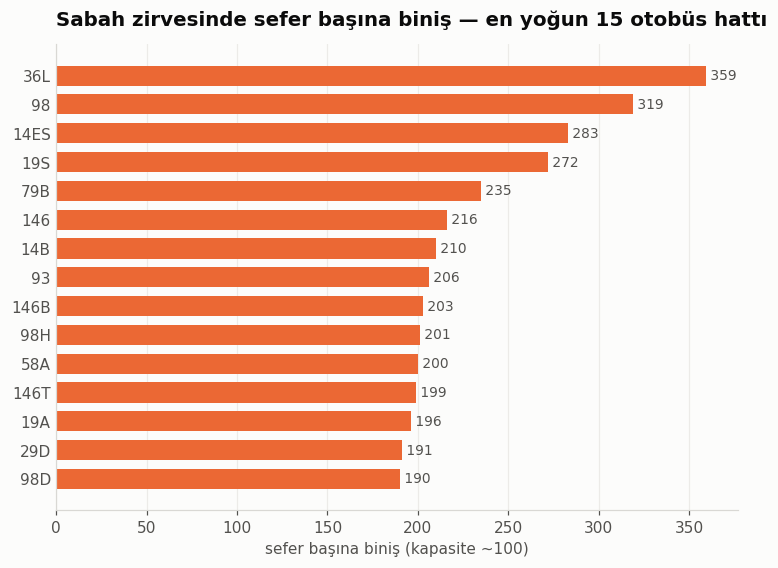

In [6]:
hat = con.execute("""
    SELECT hat_kodu, ROUND(ort_yolcu) AS gunluk_yolcu, sefer, ROUND(sefer_basi_yolcu) AS sefer_basi, yuk
    FROM hat_dilim_yuk
    WHERE saat_dilimi = 'sabah_zirve' AND sefer >= 6     -- az seferli hatlar gürültülü
    ORDER BY yuk DESC LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(8, 5.5))
yatay_cubuk(ax, hat["hat_kodu"], hat["sefer_basi"], renk=TURUNCU, fmt="{:.0f}")
ax.set_title("Sabah zirvesinde sefer başına biniş — en yoğun 15 otobüs hattı")
ax.set_xlabel("sefer başına biniş (kapasite ~100)")
kaydet(fig, "02_yogun_hatlar")
hat

Sefer başına binişin kapasitenin 2-3 katına çıktığı hatlar var. Biniş sayısı aynı anda araçtaki kişi sayısı olmadığı için
(yolcular yol boyunca iner-biner) bu "taşma" değil, ama hatların **birbirine göre** ne kadar yoğun olduğunu iyi gösteriyor.

## 6. Aktarma merkezleri

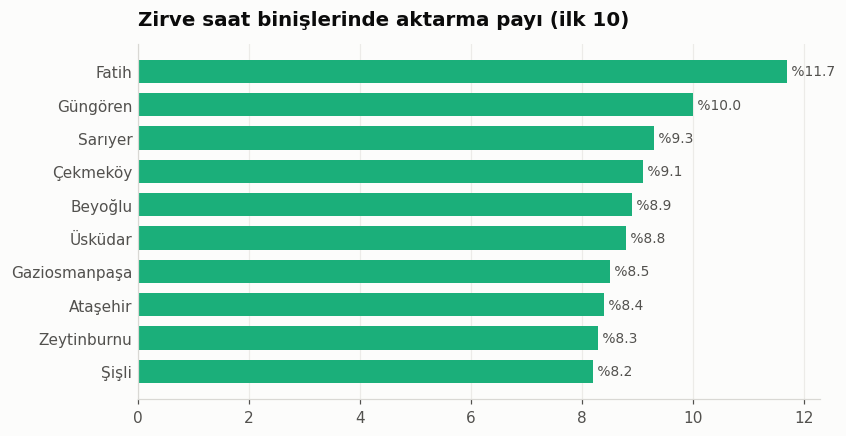

In [7]:
a = t.nlargest(10, "aktarma_orani")
fig, ax = plt.subplots(figsize=(8, 4.2))
yatay_cubuk(ax, a["ad"], a["aktarma_orani"] * 100, renk=CAMGOBEGI, fmt="%{:.1f}")
ax.set_title("Zirve saat binişlerinde aktarma payı (ilk 10)")
kaydet(fig, "02_aktarma")

Aktarma oranı, aktarmanın **yapıldığı** yerde yüksek çıkıyor. Bu yüzden listenin başında Fatih (Eminönü, Aksaray, Yenikapı), Güngören ve Sarıyer
gibi **aktarma noktaları** var. Bu ölçüt "bu ilçede oturanlar zorlanıyor mu?" sorusunu cevaplamadığı için **fırsat puanına dahil edilmedi**.
Ama başka bir fırsatı gösteriyor: aktarma merkezleri, scooter/e-bisiklet park noktaları için doğal adaylar.

## 7. Zirve saat trafiği

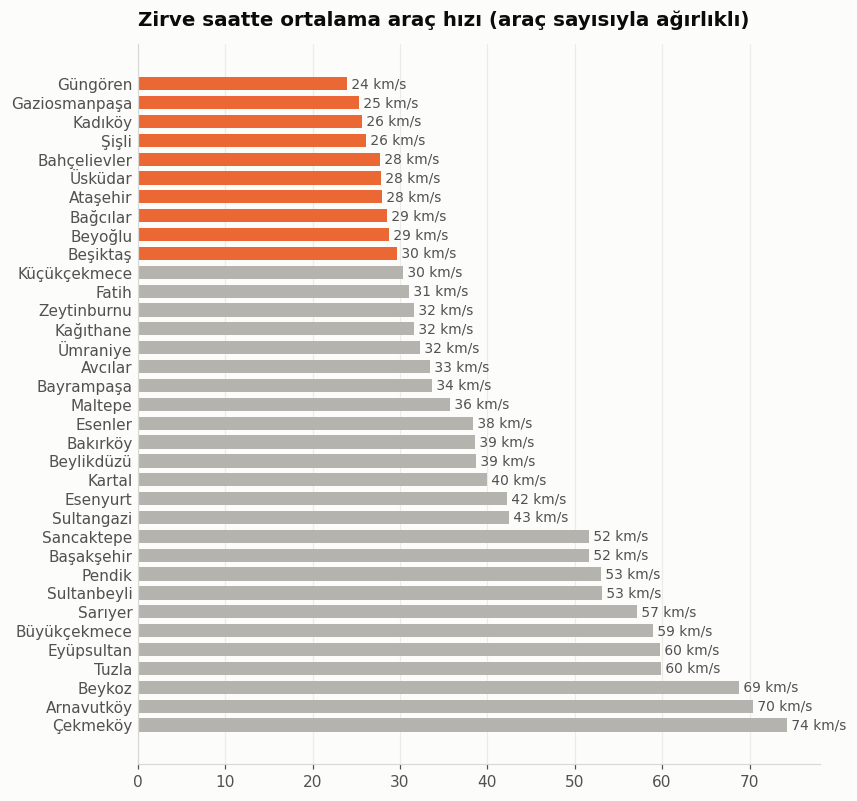

In [8]:
trafik = trafik_ilce(sorgu(con, "06_trafik_zirve.sql"))
tr = trafik[~trafik["ilce"].isin(["SILIVRI", "SILE", "CATALCA", "ADALAR"])].copy()
tr["ad"] = tr["ilce"].map(AD)
tr = tr.sort_values("zirve_hiz_kmh")

fig, ax = plt.subplots(figsize=(8, 8.5))
yatay_cubuk(ax, tr["ad"], tr["zirve_hiz_kmh"], fmt="{:.0f} km/s",
            vurgu=set(tr[tr["zirve_hiz_kmh"] < 30]["ad"]), renk=TURUNCU)
ax.set_title("Zirve saatte ortalama araç hızı (araç sayısıyla ağırlıklı)")
kaydet(fig, "02_trafik")

Turuncu ilçelerde zirve saat ortalama hızı **30 km/s'in altında**. Bu ilçelerde araçla yapılan paylaşımlı yolculuk (taksi, Uber)
trafikte sıkışıyor. Burada araç yerine **scooter / e-bisiklet** gibi trafikten etkilenmeyen alternatifler daha mantıklı.

Not: Hız, ilçedeki tüm yolların ortalaması. Otoyol geçen ilçelerde (Eyüpsultan, Sarıyer) ortalama yüksek çıkıyor.

## 8. Ölçütler arası ilişki

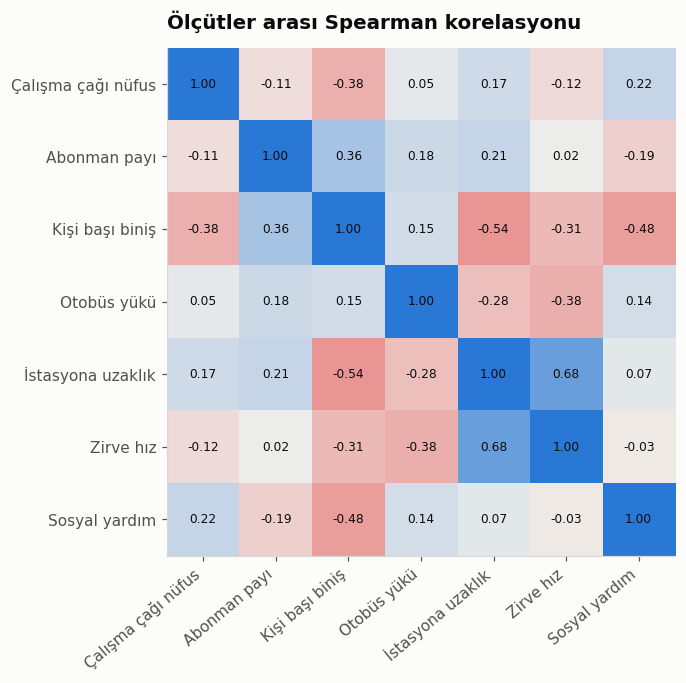

In [9]:
sy = pd.read_parquet(PROCESSED / "referans" / "ilce_sosyal_yardim.parquet")
tum = (t.merge(yuk, on="ilce").merge(erisim, on="ilce").merge(trafik, on="ilce").merge(sy, on="ilce"))
tum["sosyal_yardim_binde"] = tum["sosyal_yardim_hane"] / tum["nufus"] * 1000
kolonlar = {
    "nufus_15_64": "Çalışma çağı nüfus", "abonman_payi": "Abonman payı",
    "kisi_basi_zirve_binis": "Kişi başı biniş", "zirve_otobus_yuku": "Otobüs yükü",
    "uzak_durak_payi": "İstasyona uzaklık", "zirve_hiz_kmh": "Zirve hız",
    "sosyal_yardim_binde": "Sosyal yardım",
}
kor = tum[list(kolonlar)].rename(columns=kolonlar).corr(method="spearman")

from matplotlib.colors import LinearSegmentedColormap
iki_yon = LinearSegmentedColormap.from_list("iy", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(kor, cmap=iki_yon, vmin=-1, vmax=1)
ax.set_xticks(range(len(kor)), kor.columns, rotation=40, ha="right")
ax.set_yticks(range(len(kor)), kor.columns)
ax.grid(False)
for i in range(len(kor)):
    for j in range(len(kor)):
        ax.text(j, i, f"{kor.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color=YAZI)
ax.set_title("Ölçütler arası Spearman korelasyonu")
kaydet(fig, "02_korelasyon")

**Yorum:**
- **Kişi başı biniş** ile **istasyona uzaklık** arasında orta-güçlü negatif ilişki var (ρ ≈ −0,54): istasyondan uzak ilçeler
  toplu taşımayı daha az kullanıyor. Bu, bölüm 3'teki sorunun cevabına işaret ediyor: düşük kullanımın önemli bir kısmı **erişim sorunu**.
  (Korelasyon nedensellik değildir; gelir ve özel araç sahipliği gibi etkenler de rol oynuyor olabilir.)
- Ölçütler birbirinin kopyası değil (korelasyonlar çok yüksek değil); her biri puana farklı bir bilgi katıyor.

In [10]:
tum.to_csv(PROCESSED / "ilce_metrikleri.csv", index=False)
print(f"{len(tum)} ilçe, {tum.shape[1]} kolon kaydedildi -> data/processed/ilce_metrikleri.csv")

35 ilçe, 22 kolon kaydedildi -> data/processed/ilce_metrikleri.csv
